In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Full code with leptons + beta equilibrium + charge neutrality
# ============================================================
model = 'tvm'          # or 'cs'
isos_repulsion = 'eq'  # or 'neq'
# ----------------------------
# physical/constants
# ----------------------------
Nc = 3.0
g = 2.0

# masses in GeV
mp = 0.9382720813
mn = 0.9395654133
me = 0.000511
mmu = 0.10566



# ----------------------------
# interaction parameters
# ----------------------------
if isos_repulsion == 'eq':
    an = 37.33
    bn = 560.08
    apn = 53.72
    bpn = 1.0 * bn
    print(r'isospin-blind repulsion $b_n = b_{pn}$')

elif isos_repulsion == 'neq':
    an = 26.78
    bn = 363.72
    apn = 64.67
    bpn = 756.4
    print(r'isospin-dependent repulsion $b_n \neq b_{pn}$')


# ----------------------------
# helper functions
# ----------------------------
def integrate_simpson(f, a, b, n=1000):
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan
    if b < a:
        return 0.0
    if abs(b - a) < 1e-14:
        return 0.0
    if n % 2 == 1:
        n += 1
    h = (b - a) / n
    s = f(a) + f(b)
    x = a
    for i in range(1, n):
        x += h
        s += (4.0 if (i % 2) == 1 else 2.0) * f(x)
    return s * (h / 3.0)


def gss(f, a, b, tol=1e-7, max_iter=500):
    gr = (np.sqrt(5.0) + 1.0) / 2.0
    c = b - (b - a) / gr
    d = a + (b - a) / gr
    fc = f(c)
    fd = f(d)

    for _ in range(max_iter):
        if abs(b - a) < tol:
            break

        if (not np.isfinite(fc)) and (not np.isfinite(fd)):
            c = b - (b - a) / gr
            d = a + (b - a) / gr
            fc = f(c)
            fd = f(d)
            continue

        if not np.isfinite(fc):
            a = c
            c = d
            fc = fd
            d = a + (b - a) / gr
            fd = f(d)
            continue

        if not np.isfinite(fd):
            b = d
            d = c
            fd = fc
            c = b - (b - a) / gr
            fc = f(c)
            continue

        if fc < fd:
            b = d
            d = c
            fd = fc
            c = b - (b - a) / gr
            fc = f(c)
        else:
            a = c
            c = d
            fc = fd
            d = a + (b - a) / gr
            fd = f(d)

    return 0.5 * (a + b)


# ----------------------------
# ideal quark energy densities
# ----------------------------

def f1(q):
    return q * np.sqrt(lam**2 + q**2) * np.sqrt(mu**2 + q**2)

def f2(q):
    return q * np.sqrt(lam**2 + q**2) * np.sqrt(md**2 + q**2)

def euid(kbu, y, N=1000):
    k = g / (2.0 * np.pi**2)
    result = (1.0 + y) / (2.0 - y) * integrate_simpson(f1, 0.0, kbu / Nc, n=N)
    return Nc * k * result

def edid(kbu, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f2, 0.0, kbu / Nc, n=N)
    return Nc * k * result


# ----------------------------
# ideal nucleon energy densities
# ----------------------------

def f3(k):
    return k**2 * np.sqrt(mn**2 + k**2)

def f4(k):
    return k**2 * np.sqrt(mp**2 + k**2)

def enid(kbu, kfn, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f3, kbu, kfn, n=N)
    return k * result

def epid(kbu, kfp, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f4, kbu, kfp, n=N)
    return k * result


# ----------------------------
# ideal quark baryon densities
# ----------------------------

def f5(q):
    return q * np.sqrt(lam**2 + q**2)

def f6(q):
    return q * np.sqrt(lam**2 + q**2)

def nuid(kbu, y, N=1000):
    k = g / (2.0 * np.pi**2)
    result = (1.0 + y) / (2.0 - y) * integrate_simpson(f5, 0.0, kbu / Nc, n=N)
    return Nc * k * result

def ndid(kbu, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f6, 0.0, kbu / Nc, n=N)
    return Nc * k * result


# ----------------------------
# ideal nucleon baryon densities
# ----------------------------
def f7(k):
    return k**2

def nnid(kbu, kfn, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f7, kbu, kfn, n=N)
    return k * result

def npid(kbu, kfp, N=1000):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f7, kbu, kfp, n=N)
    return k * result


# ----------------------------
# excluded-volume functions
# ----------------------------
def f_tvm(x):
    return np.exp(-x - 0.5 * x**2)

def f_cs(x):
    if x >= 4.0:
        return np.nan
    return np.exp(-(4.0 - 3.0 * x) * x / (1.0 - x)**2)


# ----------------------------
# solvers for momenta
# ----------------------------
def kbu_solver(rhob, fq, y):
    k = g / (2.0 * np.pi**2)
    w = (3.0 / (2.0 - y)) * k
    nq = rhob * fq
    inside = (3.0 * nq / w + lam**3)**(2.0 / 3.0) - lam**2
    return Nc * np.sqrt(max(inside, 0.0))


def kfp_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)
    x_p = bn * n_p + bpn * n_n

    f = f_tvm(x_p) if model == "tvm" else f_cs(x_p)
    if not np.isfinite(f) or f <= 0:
        return np.nan

    n_p_id = n_p / f
    val = kbu**3 + (6.0 * np.pi**2 / g) * n_p_id
    return np.cbrt(max(val, 0.0))


def kfn_solver_CS_TVM(rhob, fq, y, kbu, model="tvm"):
    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)
    x_n = bpn * n_p + bn * n_n

    f = f_tvm(x_n) if model == "tvm" else f_cs(x_n)
    if not np.isfinite(f) or f <= 0:
        return np.nan

    n_n_id = n_n / f
    val = kbu**3 + (6.0 * np.pi**2 / g) * n_n_id
    return np.cbrt(max(val, 0.0))


# ----------------------------
# hadron+quark energy only
# ----------------------------
def energy_hq_of_fq_y(
    fq,
    rhob,
    y,
    *,
    model,
    bn, bpn, an, apn,
    kbu_solver,
    kfp_solver_CS_TVM,
    kfn_solver_CS_TVM,
    euid, edid, enid, epid,
    f_tvm, f_cs,
):
    if y <= 0.0 or y >= 0.5:
        return np.nan

    kbu = kbu_solver(rhob, fq, y)
    kfp = kfp_solver_CS_TVM(rhob, fq, y, kbu, model=model)
    kfn = kfn_solver_CS_TVM(rhob, fq, y, kbu, model=model)

    if (not np.isfinite(kbu)) or (not np.isfinite(kfp)) or (not np.isfinite(kfn)):
        return np.nan

    eu = euid(kbu, y=y)
    ed = edid(kbu)
    en = enid(kbu, kfn)
    ep = epid(kbu, kfp)

    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)

    x_p = bn * n_p + bpn * n_n
    x_n = bpn * n_p + bn * n_n

    if model == "cs" and ((x_p >= 4.0) or (x_n >= 4.0)):
        return np.nan

    fp = f_tvm(x_p) if model == "tvm" else f_cs(x_p)
    fn = f_tvm(x_n) if model == "tvm" else f_cs(x_n)

    if (not np.isfinite(fp)) or (not np.isfinite(fn)) or (fp <= 0) or (fn <= 0):
        return np.nan

    nuclear_int = fp * ep + fn * en - an * (n_p**2 + n_n**2) - 2.0 * apn * n_p * n_n
    return eu + ed + nuclear_int


# ----------------------------
# lepton sector
# ----------------------------
def lepton_kf_from_mu(mu_l, m_l):
    x = mu_l**2 - m_l**2
    return np.sqrt(max(x, 0.0))

def lepton_density_from_mu(mu_l, m_l):
    if mu_l <= m_l:
        return 0.0
    kf = lepton_kf_from_mu(mu_l, m_l)
    return kf**3 / (3.0 * np.pi**2)

def lepton_energy_density_from_mu(mu_l, m_l, nint=1000):
    if mu_l <= m_l:
        return 0.0
    kf = lepton_kf_from_mu(mu_l, m_l)

    def f(k):
        return k**2 * np.sqrt(k**2 + m_l**2)

    return (1.0 / np.pi**2) * integrate_simpson(f, 0.0, kf, n=nint)


# ----------------------------
# charge density of hadron+quark sector
# ----------------------------
def charge_density_hq(rhob, fq, y):
    kbu = kbu_solver(rhob, fq, y)

    if not np.isfinite(kbu):
        return np.nan

    n_p = rhob * (1.0 - fq) * y

    # nuid and ndid in your code are baryon densities carried by quarks
    # so multiply by 3 to get quark number densities
    n_u = 3.0 * nuid(kbu, y)
    n_d = 3.0 * ndid(kbu)

    return n_p + (2.0 / 3.0) * n_u - (1.0 / 3.0) * n_d


# ----------------------------
# chemical potentials
# ----------------------------
def mu_Q_fd(rhob, fq, y, dy=1e-5):
    y1 = max(1.0e-8, y - dy)
    y2 = min(0.5 - 1.0e-8, y + dy)

    e1 = energy_hq_of_fq_y(
        fq, rhob, y1,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )

    e2 = energy_hq_of_fq_y(
        fq, rhob, y2,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )

    if (not np.isfinite(e1)) or (not np.isfinite(e2)):
        return np.nan

    return (e2 - e1) / (rhob * (y2 - y1))


def mu_e_from_y(rhob, fq, y):
    muQ = mu_Q_fd(rhob, fq, y)
    if not np.isfinite(muQ):
        return np.nan
    return -muQ


# ----------------------------
# charge neutrality
# ----------------------------
def neutrality_residual(y, rhob, fq):
    mu_e = mu_e_from_y(rhob, fq, y)
    if not np.isfinite(mu_e):
        return np.nan

    rho_hq = charge_density_hq(rhob, fq, y)
    rho_e = lepton_density_from_mu(mu_e, me)
    rho_mu = lepton_density_from_mu(mu_e, mmu)

    if not np.isfinite(rho_hq):
        return np.nan

    return rho_hq - (rho_e + rho_mu)


def solve_y_beta_equilibrium(rhob, fq, y_min=1.0e-6, y_max=0.5 - 1.0e-6, nscan=300):
    ys = np.linspace(y_min, y_max, nscan)
    vals = []

    for y in ys:
        vals.append(neutrality_residual(y, rhob, fq))

    vals = np.asarray(vals, dtype=float)

    ystar = np.nan

    for i in range(len(ys) - 1):
        a = ys[i]
        b = ys[i + 1]
        fa = vals[i]
        fb = vals[i + 1]

        if (not np.isfinite(fa)) or (not np.isfinite(fb)):
            continue

        if abs(fa) < 1e-12:
            ystar = a
            break

        if fa * fb < 0.0:
            left = a
            right = b
            fl = fa

            for _ in range(200):
                mid = 0.5 * (left + right)
                fm = neutrality_residual(mid, rhob, fq)

                if not np.isfinite(fm):
                    break

                if abs(fm) < 1e-12:
                    left = mid
                    right = mid
                    break

                if fl * fm <= 0.0:
                    right = mid
                else:
                    left = mid
                    fl = fm

            ystar = 0.5 * (left + right)
            break

    if not np.isfinite(ystar):
        return np.nan, np.nan, np.nan, np.nan

    mu_e = mu_e_from_y(rhob, fq, ystar)
    eps_e = lepton_energy_density_from_mu(mu_e, me)
    eps_mu = lepton_energy_density_from_mu(mu_e, mmu)

    return ystar, mu_e, eps_e, eps_mu


# ----------------------------
# full energy with leptons
# ----------------------------
def total_energy_beta(fq, rhob):
    ystar, mu_e, eps_e, eps_mu = solve_y_beta_equilibrium(rhob, fq)

    if not np.isfinite(ystar):
        return np.nan

    eps_hq = energy_hq_of_fq_y(
        fq, rhob, ystar,
        model=model,
        bn=bn, bpn=bpn, an=an, apn=apn,
        kbu_solver=kbu_solver,
        kfp_solver_CS_TVM=kfp_solver_CS_TVM,
        kfn_solver_CS_TVM=kfn_solver_CS_TVM,
        euid=euid, edid=edid, enid=enid, epid=epid,
        f_tvm=f_tvm, f_cs=f_cs,
    )

    if not np.isfinite(eps_hq):
        return np.nan

    return eps_hq + eps_e + eps_mu


# ----------------------------
# main loop: solve fq and y*
# ----------------------------
colors = ['blue', 'deepskyblue', 'cyan', 'springgreen', 'magenta', 'purple']

energy_density_list = []
fq_star_list = []
y_star_list = []
mu_e_list = []
eps_e_list = []
eps_mu_list = []

for rhob in rhob_list:
    def f_to_minimize(fq):
        return total_energy_beta(fq, rhob)

    fq_star = gss(f_to_minimize, fq_min, fq_max, tol=1e-7)
    E_star = f_to_minimize(fq_star)

    y_star, mu_e_star, eps_e_star, eps_mu_star = solve_y_beta_equilibrium(rhob, fq_star)

    fq_star_list.append(fq_star)
    energy_density_list.append(E_star)
    y_star_list.append(y_star)
    mu_e_list.append(mu_e_star)
    eps_e_list.append(eps_e_star)
    eps_mu_list.append(eps_mu_star)

energy_density_arr = np.asarray(energy_density_list, dtype=float)
fq_star_arr = np.asarray(fq_star_list, dtype=float)
y_star_arr = np.asarray(y_star_list, dtype=float)
mu_e_arr = np.asarray(mu_e_list, dtype=float)
eps_e_arr = np.asarray(eps_e_list, dtype=float)
eps_mu_arr = np.asarray(eps_mu_list, dtype=float)


# ----------------------------
# thermodynamics
# ----------------------------
mu_b = np.gradient(energy_density_arr, rhob_list, edge_order=2)
mu_bb = np.gradient(mu_b, rhob_list, edge_order=2)
vs2 = rhob_list / mu_b * mu_bb


# ----------------------------
# plots
# ----------------------------
plt.figure()
plt.plot(rhob_list / rho0, vs2, color='blue', lw=1.2, label=r'$\beta$ equilibrium + leptons')
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'$v_s^2$')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(rhob_list / rho0, y_star_arr, color='red', lw=1.2)
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'$y_\star$')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(rhob_list / rho0, fq_star_arr, color='black', lw=1.2)
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'$f_{q,\star}$')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(rhob_list / rho0, mu_e_arr, color='purple', lw=1.2, label=r'$\mu_e$')
plt.axhline(mmu, color='gray', ls='--', lw=1.0, label=r'$m_\mu$')
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'chemical potential [GeV]')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(rhob_list / rho0, eps_e_arr, color='green', lw=1.2, label=r'$\epsilon_e$')
plt.plot(rhob_list / rho0, eps_mu_arr, color='orange', lw=1.2, label=r'$\epsilon_\mu$')
plt.xlabel(r'$\rho_B/\rho_0$')
plt.ylabel(r'energy density')
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# optional print table
# ----------------------------
for i, rhob in enumerate(rhob_list):
    print(
        f"rhob={rhob:.6e}  "
        f"fq*={fq_star_arr[i]:.6f}  "
        f"y*={y_star_arr[i]:.6f}  "
        f"mu_e={mu_e_arr[i]:.6f}  "
        f"E={energy_density_arr[i]:.6e}"
    )



isospin-blind repulsion $b_n = b_{pn}$


KeyboardInterrupt: 

In [2]:

g =2; mp = mn = 0.938 #GeV/c**2
Nc = 3; mu = md = mp/Nc; lam = 0.2 #GeV200;
rho0 = 1.23e-3  #GeV^3
rhob_list = np.linspace(1e-6, 5.0, 10) * rho0
y = 0.1; fq_min = 1e-3; fq_max = 1.0
fq_list = np.linspace(fq_min, fq_max, 10)
print(len(fq_list))



10


/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_92563/1093067305.py:51: RuntimeWarning: overflow encountered in scalar multiply
  return s * h / 3.0
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_92563/1093067305.py:379: RuntimeWarning: overflow encountered in scalar multiply
  if fa * fb < 0.0:
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_92563/1093067305.py:215: RuntimeWarning: overflow encountered in scalar divide
  n_p_id = n_p / f
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_92563/1093067305.py:227: RuntimeWarning: overflow encountered in scalar divide
  n_n_id = n_n / f
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_92563/1093067305.py:216: RuntimeWarning: overflow encountered in scalar multiply
  val = kbu**3 + (6.0 * np.pi**2 / g) * n_p_id
/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_92563/1093067305.py:228: RuntimeWarning: overflow encountered in scalar multiply
  val = kbu**3 + (6.0 * np.pi**2 / g) *

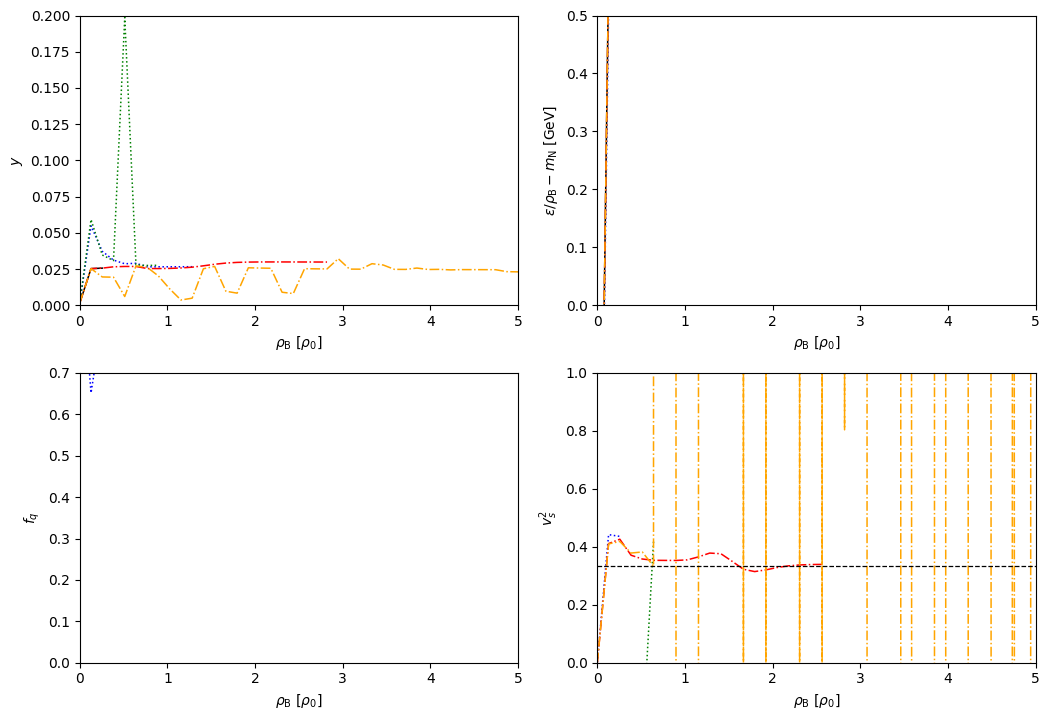

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Quarkyonic matter: faster version
#   First solve y(fq) for each density
#   Then minimize energy over fq
# ============================================================

Nc = 3.0
g = 2.0

mp = 0.9382720813
mn = 0.9395654133
me = 0.000511
mmu = 0.10566

m_uq = 0.0
m_dq = 0.0
lam_q = 0.3

rho0 = 0.16
rhob_red = np.linspace(1.0e-4, 5.0, 40)
rhob_list = rhob_red * rho0

fq_min = 0.0
fq_max = 1.0

NINT =  150
YSCAN = 50
GSS_TOL = 1e-3

# coarse fq grid for solving y first
FQ_GRID_SIZE = 30


def integrate_simpson(f, a, b, n=400):
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan
    if b < a:
        return 0.0
    if abs(b - a) < 1e-14:
        return 0.0
    if n % 2 == 1:
        n += 1
    h = (b - a) / n
    s = f(a) + f(b)
    for i in range(1, n):
        x = a + i * h
        s += (4.0 if i % 2 == 1 else 2.0) * f(x)
    return s * h / 3.0


def gss(f, a, b, tol=1e-6, max_iter=200):
    gr = (np.sqrt(5.0) + 1.0) / 2.0
    c = b - (b - a) / gr
    d = a + (b - a) / gr
    fc = f(c)
    fd = f(d)

    for _ in range(max_iter):
        if abs(b - a) < tol:
            break
        if not np.isfinite(fc):
            a = c
            c = d
            fc = fd
            d = a + (b - a) / gr
            fd = f(d)
            continue
        if not np.isfinite(fd):
            b = d
            d = c
            fd = fc
            c = b - (b - a) / gr
            fc = f(c)
            continue
        if fc < fd:
            b = d
            d = c
            fd = fc
            c = b - (b - a) / gr
            fc = f(c)
        else:
            a = c
            c = d
            fc = fd
            d = a + (b - a) / gr
            fd = f(d)
    return 0.5 * (a + b)


# ----------------------------
# ideal quark sector
# ----------------------------
def f1(q):
    return q * np.sqrt(lam_q**2 + q**2) * np.sqrt(m_uq**2 + q**2)

def f2(q):
    return q * np.sqrt(lam_q**2 + q**2) * np.sqrt(m_dq**2 + q**2)

def euid(kbu, y, N=NINT):
    k = g / (2.0 * np.pi**2)
    result = (1.0 + y) / (2.0 - y) * integrate_simpson(f1, 0.0, kbu / Nc, n=N)
    return Nc * k * result

def edid(kbu, N=NINT):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f2, 0.0, kbu / Nc, n=N)
    return Nc * k * result


# ----------------------------
# ideal nucleon sector
# ----------------------------
def f3(k):
    return k**2 * np.sqrt(mn**2 + k**2)

def f4(k):
    return k**2 * np.sqrt(mp**2 + k**2)

def enid(kbu, kfn, N=NINT):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f3, kbu, kfn, n=N)
    return k * result

def epid(kbu, kfp, N=NINT):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f4, kbu, kfp, n=N)
    return k * result


# ----------------------------
# ideal quark baryon densities
# ----------------------------
def f5(q):
    return q * np.sqrt(lam_q**2 + q**2)

def f6(q):
    return q * np.sqrt(lam_q**2 + q**2)

def nuid(kbu, y, N=NINT):
    k = g / (2.0 * np.pi**2)
    result = (1.0 + y) / (2.0 - y) * integrate_simpson(f5, 0.0, kbu / Nc, n=N)
    return Nc * k * result

def ndid(kbu, N=NINT):
    k = g / (2.0 * np.pi**2)
    result = integrate_simpson(f6, 0.0, kbu / Nc, n=N)
    return Nc * k * result


# ----------------------------
# excluded-volume factors
# ----------------------------
def f_tvm(x):
    return np.exp(-x - 0.5 * x**2)

def f_cs(x):
    if x >= 4.0:
        return np.nan
    return np.exp(-(4.0 - 3.0 * x) * x / (1.0 - x)**2)

def f_vdw(x):
    if x >= 1.0:
        return np.nan
    return 1.0 - x


def get_interaction_params(isos_repulsion):
    if isos_repulsion == 'eq':
        an = 37.33
        bn = 560.08
        apn = 53.72
        bpn = 1.0 * bn
    elif isos_repulsion == 'neq':
        an = 26.78
        bn = 363.72
        apn = 64.67
        bpn = 756.4
    else:
        raise ValueError("isos_repulsion must be 'eq' or 'neq'")
    return an, bn, apn, bpn


def available_factor(model, x):
    if model == 'tvm':
        return f_tvm(x)
    elif model == 'cs':
        return f_cs(x)
    elif model == 'vdw':
        return f_vdw(x)
    else:
        raise ValueError("model must be 'vdw', 'cs', or 'tvm'")


# ----------------------------
# momenta
# ----------------------------
def kbu_solver(rhob, fq, y):
    k = g / (2.0 * np.pi**2)
    w = (3.0 / (2.0 - y)) * k
    nq = rhob * fq
    inside = (3.0 * nq / w + lam_q**3)**(2.0 / 3.0) - lam_q**2
    return Nc * np.sqrt(max(inside, 0.0))


def kfp_solver(rhob, fq, y, kbu, model, bn, bpn):
    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)
    x_p = bn * n_p + bpn * n_n
    f = available_factor(model, x_p)
    if not np.isfinite(f) or f <= 0.0:
        return np.nan
    n_p_id = n_p / f
    val = kbu**3 + (6.0 * np.pi**2 / g) * n_p_id
    return np.cbrt(max(val, 0.0))


def kfn_solver(rhob, fq, y, kbu, model, bn, bpn):
    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)
    x_n = bpn * n_p + bn * n_n
    f = available_factor(model, x_n)
    if not np.isfinite(f) or f <= 0.0:
        return np.nan
    n_n_id = n_n / f
    val = kbu**3 + (6.0 * np.pi**2 / g) * n_n_id
    return np.cbrt(max(val, 0.0))


# ----------------------------
# HQ energy
# ----------------------------
def energy_hq_of_fq_y(fq, rhob, y, model, an, bn, apn, bpn):
    if y <= 0.0 or y >= 0.5:
        return np.nan

    kbu = kbu_solver(rhob, fq, y)
    kfp = kfp_solver(rhob, fq, y, kbu, model, bn, bpn)
    kfn = kfn_solver(rhob, fq, y, kbu, model, bn, bpn)

    if not np.isfinite(kbu) or not np.isfinite(kfp) or not np.isfinite(kfn):
        return np.nan

    eu = euid(kbu, y=y)
    ed = edid(kbu)
    en = enid(kbu, kfn)
    ep = epid(kbu, kfp)

    n_p = rhob * (1.0 - fq) * y
    n_n = rhob * (1.0 - fq) * (1.0 - y)

    x_p = bn * n_p + bpn * n_n
    x_n = bpn * n_p + bn * n_n

    fp = available_factor(model, x_p)
    fn = available_factor(model, x_n)

    if not np.isfinite(fp) or not np.isfinite(fn) or fp <= 0.0 or fn <= 0.0:
        return np.nan

    nuclear_term = fp * ep + fn * en - an * (n_p**2 + n_n**2) - 2.0 * apn * n_p * n_n
    return eu + ed + nuclear_term


# ----------------------------
# leptons
# ----------------------------
def lepton_kf_from_mu(mu_l, m_l):
    x = mu_l**2 - m_l**2
    return np.sqrt(max(x, 0.0))

def lepton_density_from_mu(mu_l, m_l):
    if mu_l <= m_l:
        return 0.0
    kf = lepton_kf_from_mu(mu_l, m_l)
    return kf**3 / (3.0 * np.pi**2)

def lepton_energy_density_from_mu(mu_l, m_l, nint=NINT):
    if mu_l <= m_l:
        return 0.0
    kf = lepton_kf_from_mu(mu_l, m_l)

    def f(k):
        return k**2 * np.sqrt(k**2 + m_l**2)

    return (1.0 / np.pi**2) * integrate_simpson(f, 0.0, kf, n=nint)


# ----------------------------
# charge density
# ----------------------------
def charge_density_hq(rhob, fq, y):
    kbu = kbu_solver(rhob, fq, y)
    if not np.isfinite(kbu):
        return np.nan

    n_p = rhob * (1.0 - fq) * y
    n_u = 3.0 * nuid(kbu, y)
    n_d = 3.0 * ndid(kbu)

    return n_p + (2.0 / 3.0) * n_u - (1.0 / 3.0) * n_d


# ----------------------------
# chemical potential by finite difference
# ----------------------------
def mu_Q_fd(rhob, fq, y, model, an, bn, apn, bpn, dy=1e-5):
    y1 = max(1e-8, y - dy)
    y2 = min(0.5 - 1e-8, y + dy)

    e1 = energy_hq_of_fq_y(fq, rhob, y1, model, an, bn, apn, bpn)
    e2 = energy_hq_of_fq_y(fq, rhob, y2, model, an, bn, apn, bpn)

    if not np.isfinite(e1) or not np.isfinite(e2):
        return np.nan

    return (e2 - e1) / (rhob * (y2 - y1))


def mu_e_from_y(rhob, fq, y, model, an, bn, apn, bpn):
    muQ = mu_Q_fd(rhob, fq, y, model, an, bn, apn, bpn)
    if not np.isfinite(muQ):
        return np.nan
    return -muQ


def neutrality_residual(y, rhob, fq, model, an, bn, apn, bpn):
    mu_e = mu_e_from_y(rhob, fq, y, model, an, bn, apn, bpn)
    if not np.isfinite(mu_e):
        return np.nan

    rho_hq = charge_density_hq(rhob, fq, y)
    rho_e = lepton_density_from_mu(mu_e, me)
    rho_mu = lepton_density_from_mu(mu_e, mmu)

    if not np.isfinite(rho_hq):
        return np.nan

    return rho_hq - (rho_e + rho_mu)


# ----------------------------
# faster y solver with previous y as initial guide
# ----------------------------
def solve_y_beta_equilibrium_fast(rhob, fq, model, an, bn, apn, bpn, y_prev=None,
                                  y_min=1e-6, y_max=0.5 - 1e-6, nscan=YSCAN):

    if y_prev is None or not np.isfinite(y_prev):
        ys = np.linspace(y_min, y_max, nscan)
    else:
        left = max(y_min, y_prev - 0.05)
        right = min(y_max, y_prev + 0.05)
        ys_local = np.linspace(left, right, max(30, nscan // 2))
        ys_global = np.linspace(y_min, y_max, 25)
        ys = np.unique(np.concatenate([ys_local, ys_global]))

    vals = np.array(
        [neutrality_residual(y, rhob, fq, model, an, bn, apn, bpn) for y in ys],
        dtype=float
    )

    ystar = np.nan

    for i in range(len(ys) - 1):
        a = ys[i]
        b = ys[i + 1]
        fa = vals[i]
        fb = vals[i + 1]

        if not np.isfinite(fa) or not np.isfinite(fb):
            continue

        if abs(fa) < 1e-12:
            ystar = a
            break

        if fa * fb < 0.0:
            left = a
            right = b
            fl = fa

            for _ in range(80):
                mid = 0.5 * (left + right)
                fm = neutrality_residual(mid, rhob, fq, model, an, bn, apn, bpn)

                if not np.isfinite(fm):
                    break

                if abs(fm) < 1e-12:
                    left = mid
                    right = mid
                    break

                if fl * fm <= 0.0:
                    right = mid
                else:
                    left = mid
                    fl = fm

            ystar = 0.5 * (left + right)
            break

    if not np.isfinite(ystar):
        return np.nan, np.nan, np.nan, np.nan

    mu_e = mu_e_from_y(rhob, fq, ystar, model, an, bn, apn, bpn)
    eps_e = lepton_energy_density_from_mu(mu_e, me)
    eps_mu = lepton_energy_density_from_mu(mu_e, mmu)

    return ystar, mu_e, eps_e, eps_mu


# ----------------------------
# build y(fq) first
# ----------------------------
def precompute_y_vs_fq(rhob, model, an, bn, apn, bpn):
    fq_grid = np.linspace(fq_min, fq_max, FQ_GRID_SIZE)
    y_grid = np.full_like(fq_grid, np.nan, dtype=float)
    mu_e_grid = np.full_like(fq_grid, np.nan, dtype=float)
    eps_e_grid = np.full_like(fq_grid, np.nan, dtype=float)
    eps_mu_grid = np.full_like(fq_grid, np.nan, dtype=float)

    y_prev = None
    for i, fq in enumerate(fq_grid):
        y_star, mu_e_star, eps_e_star, eps_mu_star = solve_y_beta_equilibrium_fast(
            rhob, fq, model, an, bn, apn, bpn, y_prev=y_prev
        )
        y_grid[i] = y_star
        mu_e_grid[i] = mu_e_star
        eps_e_grid[i] = eps_e_star
        eps_mu_grid[i] = eps_mu_star
        if np.isfinite(y_star):
            y_prev = y_star

    return fq_grid, y_grid, mu_e_grid, eps_e_grid, eps_mu_grid


def interp_safe(x, xgrid, ygrid):
    mask = np.isfinite(ygrid)
    if np.count_nonzero(mask) < 2:
        return np.nan
    return np.interp(x, xgrid[mask], ygrid[mask])


def total_energy_beta_fast(fq, rhob, model, an, bn, apn, bpn,
                           fq_grid, y_grid, eps_e_grid, eps_mu_grid):
    ystar = interp_safe(fq, fq_grid, y_grid)
    eps_e = interp_safe(fq, fq_grid, eps_e_grid)
    eps_mu = interp_safe(fq, fq_grid, eps_mu_grid)

    if not np.isfinite(ystar):
        return np.nan

    eps_hq = energy_hq_of_fq_y(fq, rhob, ystar, model, an, bn, apn, bpn)
    if not np.isfinite(eps_hq):
        return np.nan

    if not np.isfinite(eps_e):
        eps_e = 0.0
    if not np.isfinite(eps_mu):
        eps_mu = 0.0

    return eps_hq + eps_e + eps_mu


# ----------------------------
# solve one model
# ----------------------------
def solve_model_fast(model, isos_repulsion):
    an, bn, apn, bpn = get_interaction_params(isos_repulsion)

    energy_density_list = []
    fq_star_list = []
    y_star_list = []
    mu_e_list = []
    eps_e_list = []
    eps_mu_list = []

    for rhob in rhob_list:
        fq_grid, y_grid, mu_e_grid, eps_e_grid, eps_mu_grid = precompute_y_vs_fq(
            rhob, model, an, bn, apn, bpn
        )

        def f_to_minimize(fq):
            return total_energy_beta_fast(
                fq, rhob, model, an, bn, apn, bpn,
                fq_grid, y_grid, eps_e_grid, eps_mu_grid
            )

        fq_star = gss(f_to_minimize, fq_min, fq_max, tol=GSS_TOL)
        E_star = f_to_minimize(fq_star)

        y_star = interp_safe(fq_star, fq_grid, y_grid)
        mu_e_star = interp_safe(fq_star, fq_grid, mu_e_grid)
        eps_e_star = interp_safe(fq_star, fq_grid, eps_e_grid)
        eps_mu_star = interp_safe(fq_star, fq_grid, eps_mu_grid)

        energy_density_list.append(E_star)
        fq_star_list.append(fq_star)
        y_star_list.append(y_star)
        mu_e_list.append(mu_e_star)
        eps_e_list.append(eps_e_star)
        eps_mu_list.append(eps_mu_star)

    energy_density_arr = np.asarray(energy_density_list, dtype=float)
    fq_star_arr = np.asarray(fq_star_list, dtype=float)
    y_star_arr = np.asarray(y_star_list, dtype=float)
    mu_e_arr = np.asarray(mu_e_list, dtype=float)
    eps_e_arr = np.asarray(eps_e_list, dtype=float)
    eps_mu_arr = np.asarray(eps_mu_list, dtype=float)

    mu_b = np.gradient(energy_density_arr, rhob_list, edge_order=2)
    mu_bb = np.gradient(mu_b, rhob_list, edge_order=2)
    vs2 = rhob_list / mu_b * mu_bb
    e_per_b_minus_mn = energy_density_arr / rhob_list - mn

    return {
        "rhob": rhob_list.copy(),
        "rhob_red": rhob_red.copy(),
        "energy_density": energy_density_arr,
        "e_per_b_minus_mn": e_per_b_minus_mn,
        "fq": fq_star_arr,
        "y": y_star_arr,
        "mu_e": mu_e_arr,
        "eps_e": eps_e_arr,
        "eps_mu": eps_mu_arr,
        "mu_b": mu_b,
        "vs2": vs2,
    }


results = {
    ("vdw", "eq"): solve_model_fast("vdw", "eq"),
    ("cs",  "eq"): solve_model_fast("cs",  "eq"),
    ("tvm", "eq"): solve_model_fast("tvm", "eq"),
    ("cs",  "neq"): solve_model_fast("cs", "neq"),
    ("tvm", "neq"): solve_model_fast("tvm", "neq"),
}


styles = {
    ("vdw", "eq"):  dict(color="black",  ls="-",  lw=1.1, label="van der Waals"),
    ("cs",  "eq"):  dict(color="blue",   ls=":",  lw=1.1, label="Carnahan-Starling"),
    ("tvm", "eq"):  dict(color="red",    ls="-.", lw=1.1, label="trivirial model"),
    ("cs",  "neq"): dict(color="green",  ls=":",  lw=1.1, label="Carnahan-Starling"),
    ("tvm", "neq"): dict(color="orange", ls="-.", lw=1.1, label="trivirial model"),
}

fig, axs = plt.subplots(2, 2, figsize=(10.6, 7.3))
(ax1, ax2), (ax3, ax4) = axs

plot_order = [
    ("vdw", "eq"),
    ("cs",  "eq"),
    ("tvm", "eq"),
    ("cs",  "neq"),
    ("tvm", "neq"),
]

for key in plot_order:
    rr = results[key]
    ax1.plot(rr["rhob_red"], rr["y"], **styles[key])
    ax2.plot(rr["rhob_red"], rr["e_per_b_minus_mn"], **styles[key])
    ax3.plot(rr["rhob_red"], rr["fq"], **styles[key])
    ax4.plot(rr["rhob_red"], rr["vs2"], **styles[key])

ax1.set_xlim(0, 5)
ax1.set_ylim(0, 0.20)
ax1.set_xlabel(r'$\rho_{\mathrm{B}}\ [\rho_0]$')
ax1.set_ylabel(r'$y$')

ax2.set_xlim(0, 5)
ax2.set_ylim(0, 0.50)
ax2.set_xlabel(r'$\rho_{\mathrm{B}}\ [\rho_0]$')
ax2.set_ylabel(r'$\varepsilon/\rho_{\mathrm{B}}-m_{\mathrm{N}}\ [\mathrm{GeV}]$')

ax3.set_xlim(0, 5)
ax3.set_ylim(0, 0.70)
ax3.set_xlabel(r'$\rho_{\mathrm{B}}\ [\rho_0]$')
ax3.set_ylabel(r'$f_q$')

ax4.axhline(1.0 / 3.0, color='black', lw=0.9, ls='--')
ax4.set_xlim(0, 5)
ax4.set_ylim(0, 1.0)
ax4.set_xlabel(r'$\rho_{\mathrm{B}}\ [\rho_0]$')
ax4.set_ylabel(r'$v_s^2$')

plt.tight_layout()
plt.show()